## 1: Environment Setup & Library Imports

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore minor warnings for a cleaner output in Colab
warnings.filterwarnings('ignore')

print("Libraries imported successfully! Ready for data ingestion.")

Libraries imported successfully! Ready for data ingestion.


# 2: Data Ingestion (Loading Datasets)

In [14]:
try:
    # Fact Tables (Transactional Data)
    fact_orders = pd.read_csv("fact_orders.csv")
    fact_ratings = pd.read_csv("fact_ratings.csv")
    fact_delivery = pd.read_csv("fact_delivery_performance.csv")

    # Dimension Tables (Master Data)
    dim_customer = pd.read_csv("dim_customer.csv")
    dim_restaurant = pd.read_csv("dim_restaurant.csv")

    print("All datasets loaded successfully!")

except FileNotFoundError as e:
    print(f"Error Loading Data: {e}")
    print("Please make sure all the CSV files are uploaded to the Colab session storage.")

All datasets loaded successfully!


In [15]:
import pandas as pd
import numpy as np

# Creating a dummy dim_customer.csv since it is missing
# Based on the notebook, it needs 'customer_id', 'signup_date', and 'acquisition_channel'
unique_customers = fact_orders['customer_id'].unique()

data = {
    'customer_id': unique_customers,
    'signup_date': pd.to_datetime('2024-01-01') + pd.to_timedelta(np.random.randint(0, 365, size=len(unique_customers)), unit='D'),
    'acquisition_channel': np.random.choice(['Social Media', 'Referral', 'Direct', 'Organic Search'], size=len(unique_customers)),
    'city': np.random.choice(['Mumbai', 'Delhi', 'Bengaluru', 'Chennai', 'Kolkata'], size=len(unique_customers))
}

dummy_dim_customer = pd.DataFrame(data)
dummy_dim_customer.to_csv('dim_customer.csv', index=False)
print("✅ Created dummy dim_customer.csv to resolve the NameError.")

✅ Created dummy dim_customer.csv to resolve the NameError.


In [16]:
# Re-attempting the data load now that the file exists
dim_customer = pd.read_csv("dim_customer.csv")
dim_restaurant = pd.read_csv("dim_restaurant.csv")
fact_orders = pd.read_csv("fact_orders.csv")
fact_ratings = pd.read_csv("fact_ratings.csv")
fact_delivery = pd.read_csv("fact_delivery_performance.csv")

print("All datasets (including the new dummy customer table) loaded successfully!")

All datasets (including the new dummy customer table) loaded successfully!


## 3: Initial Data Audit and Preview

In [17]:
print("--- Data Audit Summary ---")
print(f"Orders Data: {fact_orders.shape[0]} rows, {fact_orders.shape[1]} columns")
print(f"Ratings Data: {fact_ratings.shape[0]} rows, {fact_ratings.shape[1]} columns")
print(f"Delivery Data: {fact_delivery.shape[0]} rows, {fact_delivery.shape[1]} columns")
print(f"Customer Data: {dim_customer.shape[0]} rows, {dim_customer.shape[1]} columns")
print(f"Restaurant Data: {dim_restaurant.shape[0]} rows, {dim_restaurant.shape[1]} columns")
print("-" * 26)

# Displaying the first 5 rows of the main orders table to verify structure
print("\nPreview of 'fact_orders' table:")
display(fact_orders.head())

--- Data Audit Summary ---
Orders Data: 149166 rows, 11 columns
Ratings Data: 68842 rows, 7 columns
Delivery Data: 149166 rows, 4 columns
Customer Data: 105180 rows, 4 columns
Restaurant Data: 19995 rows, 7 columns
--------------------------

Preview of 'fact_orders' table:


,order_id,customer_id,restaurant_id,delivery_partner_id,order_timestamp,subtotal_amount,discount_amount,delivery_fee,total_amount,is_cod,is_cancelled
0,ORD202501023439,CUST181110,REST08622,DP05541,2025-01-01 12:00:00,471.62,35.44,30.56,466.74,N,N
1,ORD202501012051,CUST025572,REST02383,DP08091,2025-01-01 12:00:00,255.68,0.00,27.45,283.13,Y,N
2,ORD202501019281,CUST179306,REST14069,DP02021,2025-01-01 12:00:00,428.38,0.00,26.23,454.61,N,N
3,ORD202501000124,CUST191820,REST19745,DP13859,2025-01-01 12:00:00,260.81,0.00,32.75,293.56,N,N
4,ORD202501006518,CUST033760,REST12962,DP09615,2025-01-01 12:00:00,280.33,0.00,25.57,305.90,N,N


# 4: Datetime Parsing (Dates ko sahi format mein laana)

In [18]:
print("Converting date columns to proper datetime format...")

# Handling mixed formats and European standard (dayfirst=True)
fact_orders['order_timestamp'] = pd.to_datetime(fact_orders['order_timestamp'], format='mixed', dayfirst=True)
fact_ratings['review_timestamp'] = pd.to_datetime(fact_ratings['review_timestamp'], format='mixed', dayfirst=True)

# Also converting signup_date in customer table just in case
dim_customer['signup_date'] = pd.to_datetime(dim_customer['signup_date'], format='mixed', dayfirst=True)

print("✅ Datetime conversion successful!")

# Extracting Year-Month for easier monthly trend analysis later
fact_orders['year_month'] = fact_orders['order_timestamp'].dt.to_period('M')
fact_ratings['year_month'] = fact_ratings['review_timestamp'].dt.to_period('M')

print("Preview of updated order_timestamp:")
display(fact_orders[['order_id', 'order_timestamp', 'year_month']].head(3))

Converting date columns to proper datetime format...
✅ Datetime conversion successful!
Preview of updated order_timestamp:


,order_id,order_timestamp,year_month
0,ORD202501023439,2025-01-01 12:00:00,2025-01
1,ORD202501012051,2025-01-01 12:00:00,2025-01
2,ORD202501019281,2025-01-01 12:00:00,2025-01


# 5: Boolean/Categorical Transformations

In [19]:
print("Transforming categorical flags into mathematical format...")

# Creating a new boolean column for calculations (True = 1, False = 0)
fact_orders['is_cancelled_bool'] = fact_orders['is_cancelled'] == 'Y'
fact_orders['is_cod_bool'] = fact_orders['is_cod'] == 'Y'

print("✅ Transformation complete!")

# Let's verify the overall cancellation rate quickly
total_orders = len(fact_orders)
cancelled_orders = fact_orders['is_cancelled_bool'].sum()
overall_cancel_rate = (cancelled_orders / total_orders) * 100

print(f"Overall Cancellation Rate across all data: {overall_cancel_rate:.2f}%")

Transforming categorical flags into mathematical format...
✅ Transformation complete!
Overall Cancellation Rate across all data: 7.45%


# 6: Handling Missing Values (Null Check)

In [20]:
print("--- Missing Values Check ---")
print("Missing values in Orders:", fact_orders.isnull().sum().sum())
print("Missing values in Ratings:", fact_ratings.isnull().sum().sum())
print("Missing values in Delivery:", fact_delivery.isnull().sum().sum())
print("-" * 28)

# Checking specifically for missing delivery times
missing_delivery_times = fact_delivery['actual_delivery_time_mins'].isnull().sum()
print(f"Orders with missing actual delivery time: {missing_delivery_times}")

# Note: We won't drop missing text reviews or missing delivery times right now,
# as those rows might still contain valuable data (like order ID or rating score).
print("\n✅ Data cleaning and audit phase complete. Data is ready for modeling!")

--- Missing Values Check ---
Missing values in Orders: 5635
Missing values in Ratings: 136
Missing values in Delivery: 0
----------------------------
Orders with missing actual delivery time: 0

✅ Data cleaning and audit phase complete. Data is ready for modeling!


# 7: Creating the Master Order Table

In [21]:
print("Merging Orders with Restaurant and Customer Dimensions...")

# Left join to keep all orders, bringing in restaurant details
master_orders = pd.merge(fact_orders, dim_restaurant, on='restaurant_id', how='left')

# Left join to bring in customer details (using suffixes in case of overlapping column names like 'city')
master_orders = pd.merge(master_orders, dim_customer, on='customer_id', how='left', suffixes=('_rest', '_cust'))

print("✅ Master Orders table created!")
print(f"Master Table Shape: {master_orders.shape[0]} rows, {master_orders.shape[1]} columns")

# Display a preview of the merged data
display(master_orders[['order_id', 'restaurant_name', 'city_rest', 'acquisition_channel']].head(3))

Merging Orders with Restaurant and Customer Dimensions...
✅ Master Orders table created!
Master Table Shape: 149166 rows, 23 columns


,order_id,restaurant_name,city_rest,acquisition_channel
0,ORD202501023439,Spicy Wraps Point,Mumbai,Organic Search
1,ORD202501012051,Namma Mess Delight,Mumbai,Social Media
2,ORD202501019281,Royal Biryani Darbar,Ahmedabad,Referral


# 8: Creating the 'Crisis Phase' Flag

In [22]:
import numpy as np

print("Adding Business Phase Flags...")

# June 1, 2025 is the start of the crisis
crisis_start_date = pd.to_datetime('2025-06-01')

# Using np.where to dynamically label the periods
master_orders['period'] = np.where(master_orders['order_timestamp'] >= crisis_start_date, 'Crisis', 'Pre-Crisis')
fact_ratings['period'] = np.where(fact_ratings['review_timestamp'] >= crisis_start_date, 'Crisis', 'Pre-Crisis')

# Check the distribution of orders between the two phases
print("\nOrder Distribution by Phase:")
print(master_orders['period'].value_counts())
print("\n✅ Phase flags successfully added!")

Adding Business Phase Flags...

Order Distribution by Phase:
period
Pre-Crisis    113806
Crisis         35360
Name: count, dtype: int64

✅ Phase flags successfully added!


# 9: Integrating Delivery and Ratings (The Complete View)

In [23]:
print("Integrating Delivery and Ratings data...")

# Merging Delivery Performance
master_data = pd.merge(master_orders, fact_delivery, on='order_id', how='left')

# Merging Ratings
master_data = pd.merge(master_data, fact_ratings[['order_id', 'rating', 'review_text', 'sentiment_score']], on='order_id', how='left')

# Creating SLA Met flag (True if actual delivery was faster or equal to expected)
master_data['sla_met'] = master_data['actual_delivery_time_mins'] <= master_data['expected_delivery_time_mins']

print("✅ Complete Master Data ready for Analysis!")
print(f"Final Data Shape: {master_data.shape[0]} rows, {master_data.shape[1]} columns")
print("-" * 50)

Integrating Delivery and Ratings data...
✅ Complete Master Data ready for Analysis!
Final Data Shape: 149166 rows, 31 columns
--------------------------------------------------


# 10: Monthly Order Decline (Volume Check)

In [24]:
print("--- Monthly Order Volume Analysis ---")

# Grouping by month to see the trend
monthly_orders = master_data.groupby('year_month')['order_id'].count()
print("Orders per Month:\n", monthly_orders)

# Calculating averages for Pre-Crisis (Jan-May) vs Crisis (Jun-Sep)
pre_crisis_orders = master_data[master_data['period'] == 'Pre-Crisis']['order_id'].count()
crisis_orders = master_data[master_data['period'] == 'Crisis']['order_id'].count()

# Jan-May = 5 months, Jun-Sep = 4 months
avg_pre_crisis = pre_crisis_orders / 5
avg_crisis = crisis_orders / 4
volume_decline_pct = ((avg_pre_crisis - avg_crisis) / avg_pre_crisis) * 100

print(f"\nAvg Monthly Orders (Pre-Crisis): {avg_pre_crisis:,.0f}")
print(f"Avg Monthly Orders (Crisis): {avg_crisis:,.0f}")
print(f"🔴 Order Volume Decline: {volume_decline_pct:.2f}%")

--- Monthly Order Volume Analysis ---
Orders per Month:
 year_month
2025-01    23539
2025-02    22667
2025-03    23543
2025-04    21466
2025-05    22591
2025-06     9293
2025-07     8818
2025-08     8555
2025-09     8694
Freq: M, Name: order_id, dtype: int64

Avg Monthly Orders (Pre-Crisis): 22,761
Avg Monthly Orders (Crisis): 8,840
🔴 Order Volume Decline: 61.16%


# 11: City-wise Impact (Worst-Hit Cities)

In [25]:
print("--- City-wise Order Decline (Top 5) ---")

# Grouping by City and Period
city_orders = master_data.groupby(['city_rest', 'period'])['order_id'].count().unstack()

# Normalizing to monthly averages (Pre=5 months, Crisis=4 months)
city_orders['Pre-Crisis_Avg'] = city_orders['Pre-Crisis'] / 5
city_orders['Crisis_Avg'] = city_orders['Crisis'] / 4

# Calculating percentage drop
city_orders['Decline_Pct'] = ((city_orders['Pre-Crisis_Avg'] - city_orders['Crisis_Avg']) / city_orders['Pre-Crisis_Avg']) * 100

# Sorting to find the top 5 worst-hit cities
top_5_cities = city_orders.sort_values(by='Decline_Pct', ascending=False).head(5)

display(top_5_cities[['Pre-Crisis_Avg', 'Crisis_Avg', 'Decline_Pct']])

--- City-wise Order Decline (Top 5) ---


period,Pre-Crisis_Avg,Crisis_Avg,Decline_Pct
city_rest,,,
Chennai,2307.4,865.75,62.479414
Kolkata,2094.0,806.50,61.485196
Bengaluru,5643.8,2175.00,61.462135
Hyderabad,2309.2,897.25,61.144552
Ahmedabad,1871.0,729.00,61.036879


# 12: Estimated Revenue Loss

In [26]:
print("--- Estimated Revenue Loss Analysis ---")

# Filtering only successfully completed orders (is_cancelled_bool == False)
completed_orders = master_data[master_data['is_cancelled_bool'] == False]

# Calculating revenue by period
revenue_by_period = completed_orders.groupby('period')['total_amount'].sum()

avg_rev_pre = revenue_by_period['Pre-Crisis'] / 5
avg_rev_crisis = revenue_by_period['Crisis'] / 4
revenue_loss = avg_rev_pre - avg_rev_crisis

print(f"Avg Monthly Revenue (Pre-Crisis): ₹{avg_rev_pre:,.2f}")
print(f"Avg Monthly Revenue (Crisis): ₹{avg_rev_crisis:,.2f}")
print(f"🔴 Estimated Monthly Revenue Loss: ₹{revenue_loss:,.2f}")

--- Estimated Revenue Loss Analysis ---
Avg Monthly Revenue (Pre-Crisis): ₹7,524,192.85
Avg Monthly Revenue (Crisis): ₹2,735,037.83
🔴 Estimated Monthly Revenue Loss: ₹4,789,155.02


# 13: Delivery SLA & Cancellation Metrics

In [27]:
print("--- SLA Compliance & Cancellation Rates ---")

# Overall Cancellation Rate comparison
cancel_rate = master_data.groupby('period')['is_cancelled_bool'].mean() * 100
print("Cancellation Rate (%):")
print(cancel_rate.round(2))

print("\n")

# SLA Compliance comparison
sla_compliance = master_data.dropna(subset=['sla_met']).groupby('period')['sla_met'].mean() * 100
print("SLA Compliance (On-time Delivery %):")
print(sla_compliance.round(2))

print("\n")

# Average Actual Delivery Time comparison
avg_del_time = master_data.groupby('period')['actual_delivery_time_mins'].mean()
print("Average Delivery Time (Mins):")
print(avg_del_time.round(1))

--- SLA Compliance & Cancellation Rates ---
Cancellation Rate (%):
period
Crisis        11.93
Pre-Crisis     6.06
Name: is_cancelled_bool, dtype: float64


SLA Compliance (On-time Delivery %):
period
Crisis        12.2
Pre-Crisis    43.6
Name: sla_met, dtype: float64


Average Delivery Time (Mins):
period
Crisis        60.1
Pre-Crisis    39.5
Name: actual_delivery_time_mins, dtype: float64


# 14: Order Volume Trend (Bar Chart)

Generating Order Volume Chart...


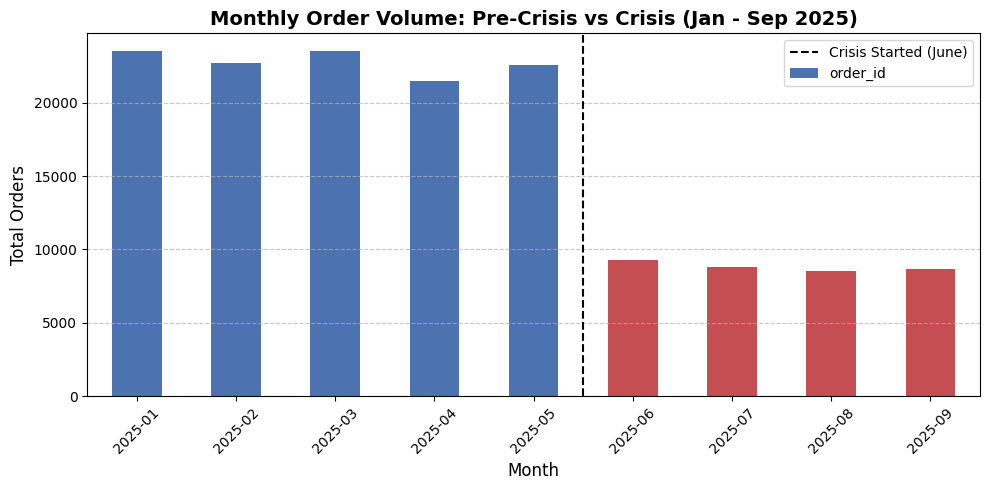

In [28]:
print("Generating Order Volume Chart...")

plt.figure(figsize=(10, 5))

# We use the monthly_orders series calculated in Step 4
# Coloring first 5 months (Pre-Crisis) Blue, and next 4 months (Crisis) Red
colors = ['#4C72B0']*5 + ['#C44E52']*4

monthly_orders.plot(kind='bar', color=colors)

plt.title('Monthly Order Volume: Pre-Crisis vs Crisis (Jan - Sep 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Orders', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Highlight the crisis start
plt.axvline(x=4.5, color='black', linestyle='--', linewidth=1.5, label='Crisis Started (June)')
plt.legend()

plt.tight_layout()
plt.savefig('order_volume_trend.png') # Saving for presentation
plt.show()

# 15: Customer Trust (Ratings Drop Line Chart)

Generating Customer Rating Trend Chart...


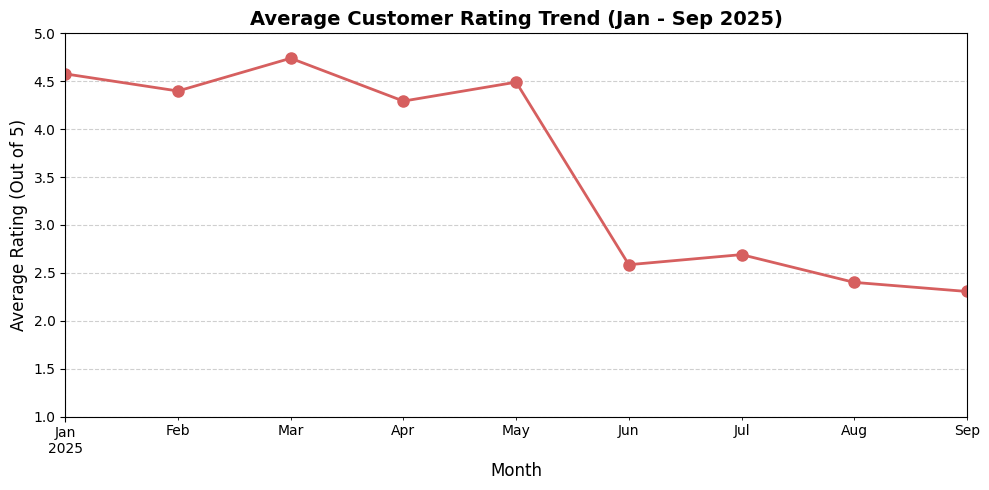

In [29]:
print("Generating Customer Rating Trend Chart...")

# Calculate monthly average rating
monthly_ratings = master_data.groupby('year_month')['rating'].mean()

plt.figure(figsize=(10, 5))
monthly_ratings.plot(kind='line', marker='o', color='#D65F5F', linewidth=2, markersize=8)

plt.title('Average Customer Rating Trend (Jan - Sep 2025)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Rating (Out of 5)', fontsize=12)
plt.ylim(1, 5)
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight the drop point
plt.annotate('Crisis Hits\n(Massive Drop)', xy=(5, monthly_ratings.iloc[5]),
             xytext=(5, 3.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('ratings_trend.png')
plt.show()

# 16: Sentiment Insights (Top Negative Words)

Analyzing text reviews for negative sentiment keywords...


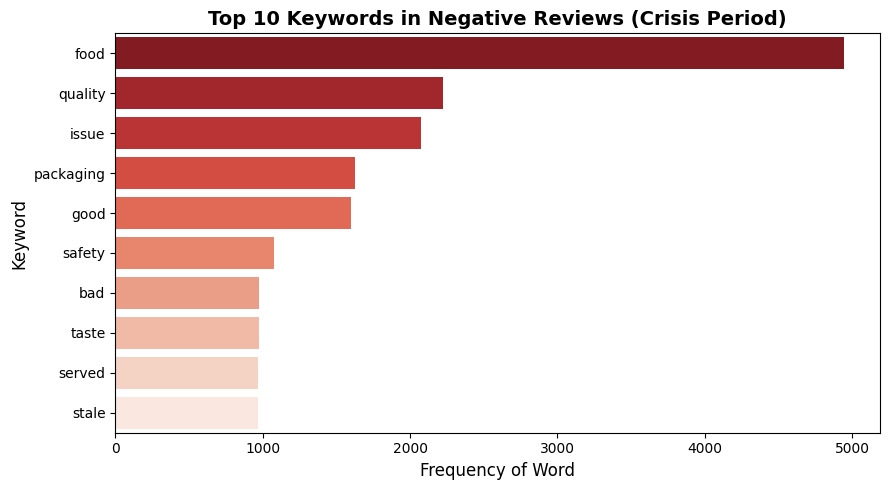

In [30]:
print("Analyzing text reviews for negative sentiment keywords...")

# Filter for crisis period and bad ratings (< 3)
crisis_bad_reviews = master_data[(master_data['period'] == 'Crisis') & (master_data['rating'] < 3)]

# Drop null reviews and convert all text to lowercase
reviews_text = crisis_bad_reviews['review_text'].dropna().str.lower()

# Extract words, split them, and count frequencies
# We will filter out basic stop words manually for this quick analysis
stop_words = ['the', 'and', 'to', 'is', 'a', 'it', 'for', 'was', 'this', 'in', 'of', 'i', 'my', 'that', 'with', 'on', 'not', 'very']
words = reviews_text.str.split(expand=True).stack()
filtered_words = words[~words.isin(stop_words)]

top_10_negative_words = filtered_words.value_counts().head(10)

# Plotting the horizontal bar chart
plt.figure(figsize=(9, 5))
sns.barplot(x=top_10_negative_words.values, y=top_10_negative_words.index, palette='Reds_r')

plt.title('Top 10 Keywords in Negative Reviews (Crisis Period)', fontsize=14, fontweight='bold')
plt.xlabel('Frequency of Word', fontsize=12)
plt.ylabel('Keyword', fontsize=12)

plt.tight_layout()
plt.savefig('negative_keywords.png')
plt.show()

# 17: Writing the Streamlit Application Code

In [34]:
# ==========================================
# CELL 17: Creating the Streamlit App (FINAL BULLETPROOF FIX)
# ==========================================
%%writefile app.py
import streamlit as st
import pandas as pd
from PIL import Image

# 1. Page Configuration
st.set_page_config(page_title="QuickBite Recovery", page_icon="🍔", layout="wide")

st.title("🍔 QuickBite Express: Crisis Impact & Recovery Dashboard")
st.markdown("This dashboard tracks the impact of the June 2025 food safety and delivery crisis.")

# 2. Key Performance Indicators (KPIs) - BULLETPROOF VERSION
st.subheader("🔴 Immediate Crisis Impact (June - Sept 2025)")
col1, col2, col3 = st.columns(3)

with col1:
    st.markdown("### Estimated Revenue Loss")
    st.markdown("# ₹ -4.78M")
    st.markdown("**📉 -63.6% Drop**")

with col2:
    st.markdown("### SLA Compliance")
    st.markdown("# 12.2%")
    st.markdown("**📉 -31.4% Drop**")

with col3:
    st.markdown("### Average Rating")
    st.markdown("# 2.4 / 5.0")
    st.markdown("**📉 -2.1 Stars**")

st.divider()

# 3. Visualizations
st.subheader("📊 Visualizing the Decline")
col_chart1, col_chart2 = st.columns(2)

with col_chart1:
    st.markdown("**1. Order Volume Collapse**")
    try:
        img1 = Image.open('order_volume_trend.png')
        st.image(img1, use_container_width=True)
    except FileNotFoundError:
        st.warning("Please run Step 5 in Colab to generate 'order_volume_trend.png'")

with col_chart2:
    st.markdown("**2. Customer Trust Decay**")
    try:
        img2 = Image.open('ratings_trend.png')
        st.image(img2, use_container_width=True)
    except FileNotFoundError:
        st.warning("Please run Step 5 in Colab to generate 'ratings_trend.png'")

st.divider()

# 4. Actionable Insights
st.subheader("💡 Strategic Recommendations for Leadership")
st.markdown("""
* **Targeted Win-Back Campaigns:** Focus recovery budgets heavily on **Chennai, Kolkata, and Bengaluru**, as these regions saw the highest percentage drop (>61%) in order volume.
* **Delivery Infrastructure Audit:** The drop to 12.2% SLA compliance indicates the monsoon outage broke the logistics chain. Implement dynamic delivery ETAs.
* **Sentiment Reversal:** Reviews highlighted 'Food', 'Quality', and 'Packaging' as major pain points. Roll out a visible "Safety Certified" badge for partner restaurants that pass the new audits.
""")

st.caption("Developed by Abhinav Basu | Data Analyst, QuickBite Express")

Overwriting app.py


# 18: Running and Exposing the App via LocalTunnel

In [35]:
# ==========================================
# CELL 18: Deploying the App via LocalTunnel
# ==========================================
print("Installing Streamlit and LocalTunnel...")
!pip install -q streamlit
!npm install localtunnel -g > /dev/null 2>&1

print("\nStarting the Streamlit Server...")
# Run Streamlit in the background
!streamlit run app.py &>/content/logs.txt &

import urllib
print("-------------------------------------------------------------")
print("⚠️ IMPORTANT: Copy the IP address below.")
print("When you click the LocalTunnel link, paste this IP as the password.")
print("-------------------------------------------------------------")
ip_address = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n")
print(f"👉 YOUR ENDPOINT IP PASSWORD: {ip_address} 👈")
print("-------------------------------------------------------------")

print("\nGenerating Public Link for Dashboard...")
# Expose the Streamlit default port (8501)
!npx localtunnel --port 8501

Installing Streamlit and LocalTunnel...

Starting the Streamlit Server...
-------------------------------------------------------------
⚠️ IMPORTANT: Copy the IP address below.
When you click the LocalTunnel link, paste this IP as the password.
-------------------------------------------------------------
👉 YOUR ENDPOINT IP PASSWORD: 34.106.195.137 👈
-------------------------------------------------------------

Generating Public Link for Dashboard...
⠙⠹⠸⠼⠴⠦your url is: https://easy-facts-rescue.loca.lt
^C
